# Data Preprocessing for Machine Learning Pipelines

## Applied Machine Learning — Boston University

Before a model can learn, the raw data must be cleaned, transformed, and structured. This notebook walks through the essential preprocessing steps and highlights **common pitfalls** that trip up even experienced practitioners.

### What you will learn
1. Why preprocessing matters
2. Handling missing values
3. Feature scaling
4. Encoding categorical variables
5. Splitting data correctly (avoiding **data leakage**)
6. Building a reproducible `sklearn` Pipeline
7. Common pitfalls — and how to avoid them

In [1]:
# Standard imports used throughout this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All imports successful!')

All imports successful!


---
## 1. Why Does Preprocessing Matter?

Most real-world datasets are **messy**: they contain missing values, features measured on very different scales, and categorical text that models cannot handle directly.

Skipping or mis-ordering preprocessing steps is one of the most common causes of:
- Models that perform well on training data but poorly in production
- Misleadingly optimistic evaluation metrics (**data leakage**)
- Numerical instability during training

We will use a synthetic dataset that mimics a real admissions dataset to illustrate these issues.

In [2]:
# --- Create a synthetic dataset ---
n = 300

data = pd.DataFrame({
    'gpa':       np.round(np.random.normal(3.2, 0.5, n).clip(0, 4), 2),
    'gre_score': np.random.randint(260, 341, n).astype(float),
    'work_exp':  np.random.randint(0, 6, n).astype(float),
    'major':     np.random.choice(['Engineering', 'Business', 'Arts', 'Science'], n),
    'admitted':  np.random.randint(0, 2, n),
})

# Inject missing values (~10% of numeric columns)
for col in ['gpa', 'gre_score', 'work_exp']:
    missing_idx = np.random.choice(n, size=int(0.10 * n), replace=False)
    data.loc[missing_idx, col] = np.nan

print('Dataset shape:', data.shape)
data.head(10)

Dataset shape: (300, 5)


,gpa,gre_score,work_exp,major,admitted
0,3.45,295.0,NaN,Business,1
1,3.13,269.0,5.0,Engineering,0
2,3.52,332.0,1.0,Arts,1
3,3.96,283.0,3.0,Arts,0
4,NaN,323.0,5.0,Science,1
5,3.08,308.0,1.0,Engineering,1
6,3.99,NaN,4.0,Business,0
7,3.58,283.0,1.0,Arts,1
8,2.97,282.0,5.0,Business,0
9,NaN,321.0,2.0,Business,0


In [3]:
# Quick look at missing values
print('Missing values per column:')
print(data.isnull().sum())
print()
print('Class balance:')
print(data['admitted'].value_counts())

Missing values per column:
gpa          30
gre_score    30
work_exp     30
major         0
admitted      0
dtype: int64

Class balance:
admitted
0    167
1    133
Name: count, dtype: int64


---
## 2. Handling Missing Values

Missing values must be handled before feeding data into most sklearn estimators. Common strategies:

| Strategy | When to use |
|---|---|
| **Mean / Median imputation** | Numeric features, roughly symmetric (mean) or skewed (median) |
| **Mode imputation** | Categorical features |
| **Drop rows / columns** | Very high missingness (> 50%) or when missingness itself is informative |
| **Model-based imputation** | When missingness has complex patterns (advanced) |

> ⚠️ **Pitfall \#1 — Imputing before splitting**
> If you impute on the *entire* dataset before splitting into train/test, the mean/median used for imputation was calculated using test-set values. This leaks information from the test set into training. **Always fit your imputer on the training set only.**

In [4]:
# ✅ Correct approach: split FIRST, then fit imputer on train set only
X = data.drop(columns=['admitted'])
y = data['admitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Training set size:', X_train.shape)
print('Test set size:    ', X_test.shape)

Training set size: (240, 4)
Test set size:     (60, 4)


In [5]:
# Demonstrate the difference between correct and incorrect imputation
numeric_cols = ['gpa', 'gre_score', 'work_exp']

# ❌ WRONG — fit on entire dataset (leaks test info)
imputer_wrong = SimpleImputer(strategy='mean')
imputer_wrong.fit(X[numeric_cols])          # uses test set statistics!
mean_wrong = imputer_wrong.statistics_

# ✅ CORRECT — fit only on training data
imputer_correct = SimpleImputer(strategy='mean')
imputer_correct.fit(X_train[numeric_cols])  # train data only
mean_correct = imputer_correct.statistics_

print('Column       | Wrong mean (leak) | Correct mean (train-only)')
print('-' * 58)
for col, wm, cm in zip(numeric_cols, mean_wrong, mean_correct):
    print(f'{col:<13}| {wm:>17.4f} | {cm:>24.4f}')

Column       | Wrong mean (leak) | Correct mean (train-only)
----------------------------------------------------------
gpa          |            3.1788 |                   3.1891
gre_score    |          299.1148 |                 298.6912
work_exp     |            2.6963 |                   2.6250


---
## 3. Feature Scaling

Many algorithms (logistic regression, SVMs, neural networks, k-NN) are sensitive to the *scale* of features. Without scaling:
- A feature ranging from 0–4 (GPA) will be dominated by one ranging from 260–340 (GRE score)
- Gradient descent converges more slowly

Two common scalers:

| Scaler | Formula | Use when |
|---|---|---|
| **StandardScaler** | z = (x − μ) / σ | Data is roughly Gaussian, no hard bounds |
| **MinMaxScaler** | x' = (x − min) / (max − min) | Need values in [0, 1]; bounded data |

> ⚠️ **Pitfall \#2 — Scaling before splitting**
> If you scale on the whole dataset, the scaler learns min/max/mean/std from test data. This is another form of data leakage. **Fit the scaler on training data only, then transform both train and test.**

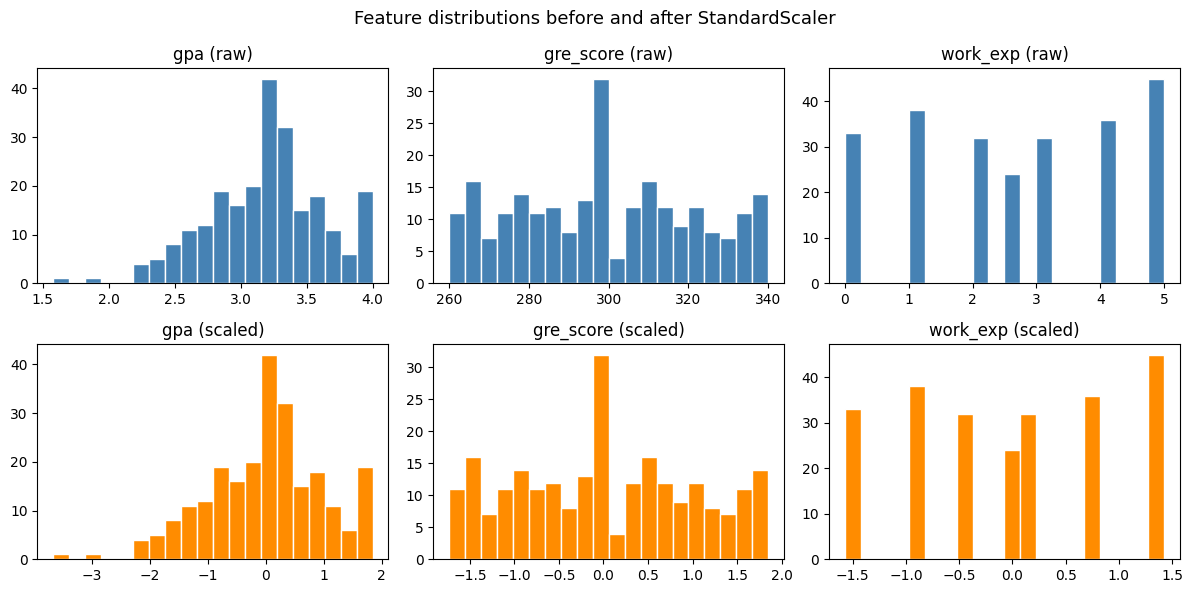

Note: shape is preserved; only the axis values change.


In [6]:
# Visualize feature distributions before and after scaling
X_train_imputed = X_train[numeric_cols].copy()
X_train_imputed[:] = imputer_correct.transform(X_train[numeric_cols])

scaler = StandardScaler()
scaler.fit(X_train_imputed)  # fit on train only
X_train_scaled = scaler.transform(X_train_imputed)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
fig.suptitle('Feature distributions before and after StandardScaler', fontsize=13)

for i, col in enumerate(numeric_cols):
    axes[0, i].hist(X_train_imputed[col], bins=20, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col} (raw)')
    axes[1, i].hist(X_train_scaled[:, i], bins=20, color='darkorange', edgecolor='white')
    axes[1, i].set_title(f'{col} (scaled)')

plt.tight_layout()
plt.savefig('scaling_comparison.png', dpi=100)
plt.show()
print('Note: shape is preserved; only the axis values change.')

---
## 4. Encoding Categorical Variables

Models require numeric input. Categorical features must be encoded.

| Encoding | When to use |
|---|---|
| **One-Hot Encoding** | Nominal categories (no order); few unique values |
| **Ordinal Encoding** | Ordinal categories (e.g., Low < Medium < High) |
| **Target Encoding** | High-cardinality categoricals (advanced; leakage risk!) |

> ⚠️ **Pitfall \#3 — Unseen categories at test time**
> If a category value appears in the test set but not in the training set, a naive encoder will raise an error or produce incorrect output. Sklearn's `OneHotEncoder` handles this with `handle_unknown='ignore'`.

> ⚠️ **Pitfall \#4 — Ordinal encoding of nominal features**
> Encoding `[Engineering=0, Business=1, Arts=2, Science=3]` implies a numeric ordering that doesn't exist. Use **One-Hot** encoding for unordered categories.

In [7]:
cat_cols = ['major']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[cat_cols])  # fit on train only

encoded_train = encoder.transform(X_train[cat_cols])
print('Original categories seen during training:', encoder.categories_)
print('Encoded training shape:', encoded_train.shape)
print('\nEncoded columns:', encoder.get_feature_names_out(cat_cols).tolist())

# Demonstrate handling of unseen category
unseen = pd.DataFrame({'major': ['Medicine']})  # not in training set
encoded_unseen = encoder.transform(unseen)
print('\nEncoded unseen category (all zeros):', encoded_unseen)

Original categories seen during training: [array(['Arts', 'Business', 'Engineering', 'Science'], dtype=object)]
Encoded training shape: (240, 4)

Encoded columns: ['major_Arts', 'major_Business', 'major_Engineering', 'major_Science']

Encoded unseen category (all zeros): [[0. 0. 0. 0.]]


---
## 5. The Data Leakage Problem

**Data leakage** occurs when information from outside the training set is used to build the model. It leads to evaluation metrics that are far too optimistic.

The most insidious form is **preprocessing leakage**: fitting transformers (imputers, scalers, encoders) on the full dataset before splitting.

Let's measure its effect empirically.

In [8]:
# ❌ WRONG: preprocess entire dataset, then split
def leaky_pipeline(X, y):
    """Demonstrates the data-leakage bug — DO NOT do this in practice."""
    X_num = X[numeric_cols].copy()
    X_cat = X[cat_cols].copy()

    # Fit on the ENTIRE dataset  ← leaks test info
    imp = SimpleImputer(strategy='mean').fit(X_num)
    X_num_imp = imp.transform(X_num)
    scl = StandardScaler().fit(X_num_imp)
    X_num_scaled = scl.transform(X_num_imp)
    enc = OneHotEncoder(sparse_output=False).fit(X_cat)
    X_cat_enc = enc.transform(X_cat)
    X_processed = np.hstack([X_num_scaled, X_cat_enc])

    # Split AFTER preprocessing
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_processed, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_tr, y_tr)
    return accuracy_score(y_te, model.predict(X_te))


# ✅ CORRECT: split first, then preprocess
def correct_pipeline(X, y):
    """Correct workflow: split before any preprocessing."""
    X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    imp = SimpleImputer(strategy='mean').fit(X_tr_raw[numeric_cols])
    X_tr_num = imp.transform(X_tr_raw[numeric_cols])
    X_te_num = imp.transform(X_te_raw[numeric_cols])  # use train statistics

    scl = StandardScaler().fit(X_tr_num)
    X_tr_num = scl.transform(X_tr_num)
    X_te_num = scl.transform(X_te_num)  # use train statistics

    enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(
        X_tr_raw[cat_cols]
    )
    X_tr_cat = enc.transform(X_tr_raw[cat_cols])
    X_te_cat = enc.transform(X_te_raw[cat_cols])

    X_tr = np.hstack([X_tr_num, X_tr_cat])
    X_te = np.hstack([X_te_num, X_te_cat])

    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_tr, y_tr)
    return accuracy_score(y_te, model.predict(X_te))


acc_leaky   = leaky_pipeline(X, y)
acc_correct = correct_pipeline(X, y)

print(f'Leaky pipeline accuracy  : {acc_leaky:.4f}  ← may be artificially inflated')
print(f'Correct pipeline accuracy: {acc_correct:.4f}  ← honest estimate')

Leaky pipeline accuracy  : 0.5500  ← may be artificially inflated
Correct pipeline accuracy: 0.5500  ← honest estimate


---
## 6. Building a Proper sklearn Pipeline

Manually tracking which transformers to fit on which data is error-prone. Sklearn's `Pipeline` and `ColumnTransformer` automate this correctly:

- **Fit** calls `fit_transform` on training data
- **Predict / transform** calls `transform` on test data using training statistics
- The entire pipeline can be used with `cross_val_score` without leakage

This is the **recommended** way to structure preprocessing in production.

In [9]:
# Define separate preprocessing steps for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     numeric_cols),
    ('cat', categorical_transformer, cat_cols),
])

# Full end-to-end pipeline: preprocessing + model
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

# Train and evaluate
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

print('Pipeline test accuracy:', accuracy_score(y_test, y_pred))

Pipeline test accuracy: 0.55


In [10]:
# Cross-validation is also safe when the entire pipeline is wrapped
cv_scores = cross_val_score(full_pipeline, X, y, cv=5, scoring='accuracy')
print(f'5-fold CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('Individual folds:', np.round(cv_scores, 4))

5-fold CV accuracy: 0.5567 ± 0.0533
Individual folds: [0.4833 0.6    0.5333 0.5333 0.6333]


---
## 7. Common Pitfalls Summary

| # | Pitfall | Consequence | Fix |
|---|---|---|---|
| 1 | Imputing before splitting | Data leakage → over-optimistic metrics | Always split first; fit imputer on train only |
| 2 | Scaling before splitting | Data leakage → over-optimistic metrics | Fit scaler on train only |
| 3 | Unseen categories at test time | Runtime errors or silent wrong results | Use `handle_unknown='ignore'` in `OneHotEncoder` |
| 4 | Ordinal encoding of nominal features | Artificial numeric ordering | Use One-Hot encoding for unordered categories |
| 5 | Scaling tree-based models | Wasted compute, no benefit | Decision trees and random forests do not need scaling |
| 6 | Using the test set to tune hyperparameters | Overfitting to the test set | Tune with cross-validation on the training set |
| 7 | Target leakage | Perfect training accuracy, terrible real-world performance | Audit each feature: would it be available at prediction time? |

In [11]:
# --- Pitfall 5: Scaling tree-based models ---
rf_pipeline_scaled = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
])

# Pipeline WITHOUT scaling for Random Forest
numeric_transformer_no_scale = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])
preprocessor_no_scale = ColumnTransformer(transformers=[
    ('num', numeric_transformer_no_scale, numeric_cols),
    ('cat', categorical_transformer,      cat_cols),
])
rf_pipeline_no_scale = Pipeline(steps=[
    ('preprocessor', preprocessor_no_scale),
    ('classifier',   RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
])

cv_scaled   = cross_val_score(rf_pipeline_scaled,   X, y, cv=5).mean()
cv_no_scale = cross_val_score(rf_pipeline_no_scale, X, y, cv=5).mean()

print(f'Random Forest with scaling:    {cv_scaled:.4f}')
print(f'Random Forest without scaling: {cv_no_scale:.4f}')
print('Result: virtually identical — scaling does not help tree-based models.')

Random Forest with scaling:    0.5300
Random Forest without scaling: 0.5233
Result: virtually identical — scaling does not help tree-based models.


In [12]:
# --- Pitfall 7: Target leakage demo ---
# Imagine we accidentally include a feature derived from the label
data_leaky = data.copy()
# 'admission_letter_sent' would only exist AFTER admission is decided
data_leaky['admission_letter_sent'] = data_leaky['admitted']  # perfect proxy!

X_leaky = data_leaky.drop(columns=['admitted'])
y_leaky = data_leaky['admitted']

X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(
    X_leaky, y_leaky, test_size=0.2, random_state=RANDOM_STATE, stratify=y_leaky
)

numeric_cols_leaky = numeric_cols + ['admission_letter_sent']
preprocessor_leaky = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols_leaky),
    ('cat', categorical_transformer, cat_cols),
])
leaky_pipeline_obj = Pipeline(steps=[
    ('preprocessor', preprocessor_leaky),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
leaky_pipeline_obj.fit(X_tr_l, y_tr_l)

acc_leaky_target  = accuracy_score(y_te_l, leaky_pipeline_obj.predict(X_te_l))
acc_correct_model = accuracy_score(y_test, full_pipeline.predict(X_test))
print(f'Leaky model test accuracy (target leakage): {acc_leaky_target:.4f}')
print(f'Correct model test accuracy:                {acc_correct_model:.4f}')
print()
print('The leaky model looks nearly perfect — a red flag that should trigger investigation.')

Leaky model test accuracy (target leakage): 1.0000
Correct model test accuracy:                0.5500

The leaky model looks nearly perfect — a red flag that should trigger investigation.


---
## 8. Checklist Before Training Any Model

Use this checklist every time you set up an ML pipeline:

- [ ] **Split first** — train/validation/test sets are defined before any preprocessing
- [ ] **Fit transformers on train only** — imputers, scalers, encoders are fit on `X_train`
- [ ] **Apply transformers to test** — use `transform` (not `fit_transform`) on `X_test`
- [ ] **Handle missing values** — choose an imputation strategy appropriate for each feature
- [ ] **Scale numeric features** — required for distance- and gradient-based models
- [ ] **Encode categoricals correctly** — One-Hot for nominal, Ordinal for ordered
- [ ] **Audit for target leakage** — every feature should be available at prediction time
- [ ] **Wrap everything in a `Pipeline`** — ensures transforms are applied consistently
- [ ] **Use cross-validation on the full pipeline** — not just the model
- [ ] **Keep the test set truly held out** — never use it for model selection or tuning

---

## Summary

Proper data preprocessing is the foundation of a trustworthy ML system. The sklearn `Pipeline` API makes it straightforward to apply all transformations in the correct order and avoid the most common sources of data leakage. Following the checklist above will save you from the majority of subtle bugs that inflate evaluation metrics and cause model failures in production.